# Inputs — explorando os workloads

Resumo e forma dos três workloads de `inputs/`: capacidade, mix de eventos,
demanda total de `ALOC` frente à memória disponível e distribuição dos tamanhos.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from models.workload.event_type import EventType
from shared.parser import parse_input

WORKLOADS = (
    "inputs/workload_simples.json",
    "inputs/workload.json",
    "inputs/workload_fragmentacao.json",
    "inputs/workload_complexo.json",
)

In [ ]:
def resumo(path):
    w = parse_input(path)
    alocs = [e for e in w.events if e.type == EventType.ALLOC]
    liberas = [e for e in w.events if e.type == EventType.FREE]
    demanda = sum(e.size for e in alocs)
    return {
        "memoria_total": w.total_memory,
        "eventos": len(w.events),
        "ALOC": len(alocs),
        "FREE": len(liberas),
        "demanda_ALOC": demanda,
        "demanda/capacidade": round(demanda / w.total_memory, 2),
        "maior_ALOC": max((e.size for e in alocs), default=0),
        "menor_ALOC": min((e.size for e in alocs), default=0),
    }


for path in WORKLOADS:
    print(path)
    for k, v in resumo(path).items():
        print(f"  {k}: {v}")
    print()

inputs/workload_simples.json
  memoria_total: 1000
  eventos: 7
  ALOC: 5
  FREE: 2
  demanda_ALOC: 1000
  demanda/capacidade: 1.0
  maior_ALOC: 300
  menor_ALOC: 100

inputs/workload.json
  memoria_total: 1200
  eventos: 15
  ALOC: 10
  FREE: 5
  demanda_ALOC: 2240
  demanda/capacidade: 1.87
  maior_ALOC: 500
  menor_ALOC: 80

inputs/workload_fragmentacao.json
  memoria_total: 600
  eventos: 10
  ALOC: 7
  FREE: 3
  demanda_ALOC: 1750
  demanda/capacidade: 2.92
  maior_ALOC: 1000
  menor_ALOC: 50

inputs/workload_complexo.json
  memoria_total: 1000
  eventos: 20
  ALOC: 15
  FREE: 5
  demanda_ALOC: 3530
  demanda/capacidade: 3.53
  maior_ALOC: 700
  menor_ALOC: 100



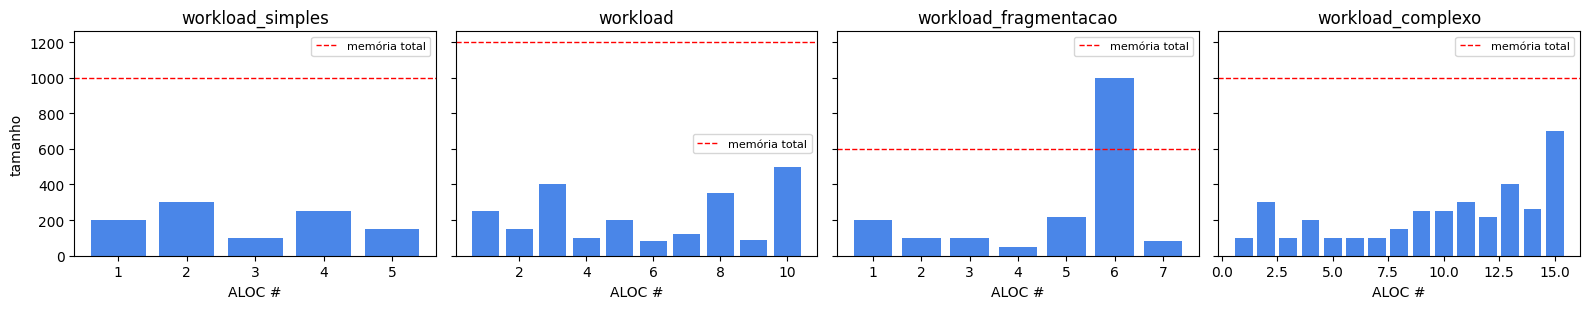

In [3]:
fig, axes = plt.subplots(1, len(WORKLOADS), figsize=(4 * len(WORKLOADS), 3.2), sharey=True)
for ax, path in zip(axes, WORKLOADS):
    w = parse_input(path)
    sizes = [e.size for e in w.events if e.type == EventType.ALLOC]
    ax.bar(range(1, len(sizes) + 1), sizes, color="#4a86e8")
    ax.axhline(w.total_memory, color="red", linestyle="--", linewidth=1, label="memória total")
    ax.set_title(Path(path).stem)
    ax.set_xlabel("ALOC #")
    ax.legend(fontsize=8)
axes[0].set_ylabel("tamanho")
fig.tight_layout()
plt.show()